In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import pandas as pd 
import numpy as np 
  
# Load the dataset 
df = pd.read_csv('Online Retail.csv') 
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/01/2010 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/01/2010 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/01/2010 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/01/2010 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/01/2010 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


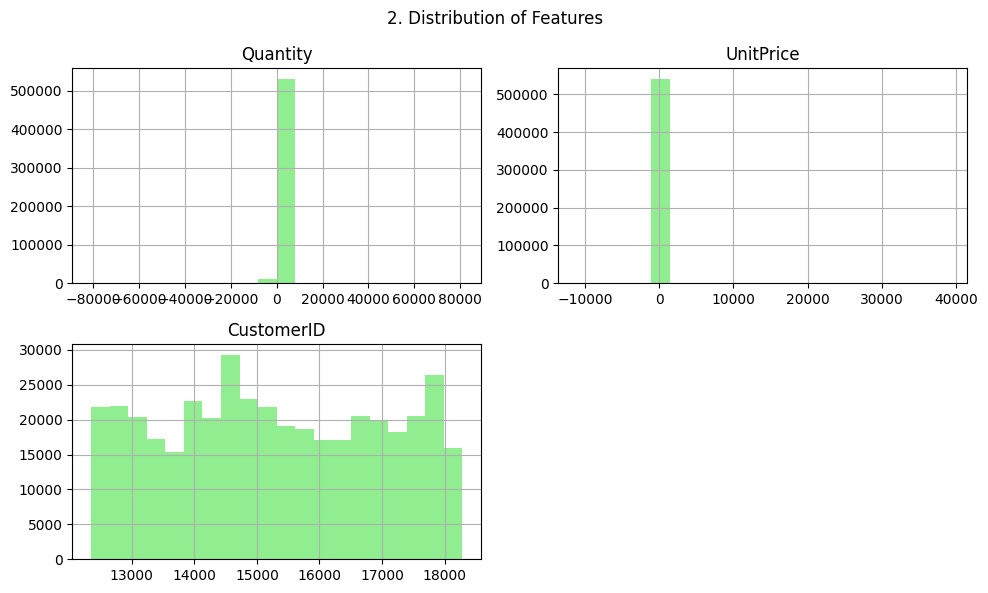

In [4]:
df.hist(bins=20, figsize=(10, 6), color='lightgreen')
plt.suptitle('2. Distribution of Features')
plt.tight_layout()
plt.show()

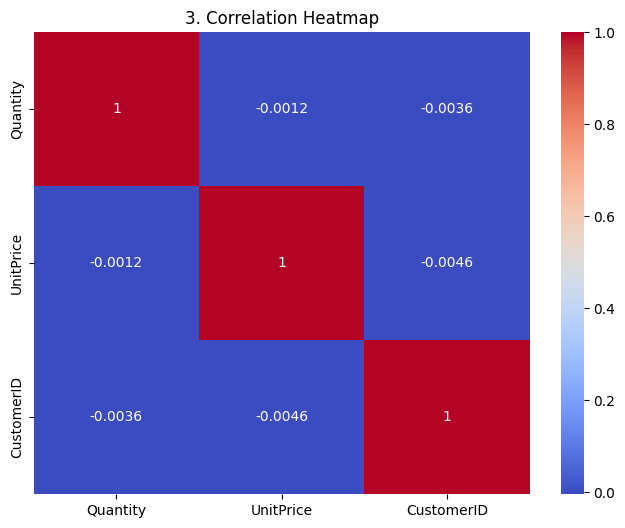

In [4]:
plt.figure(figsize=(8, 6))
correlation = df.select_dtypes(include='number').corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('3. Correlation Heatmap')
plt.show()


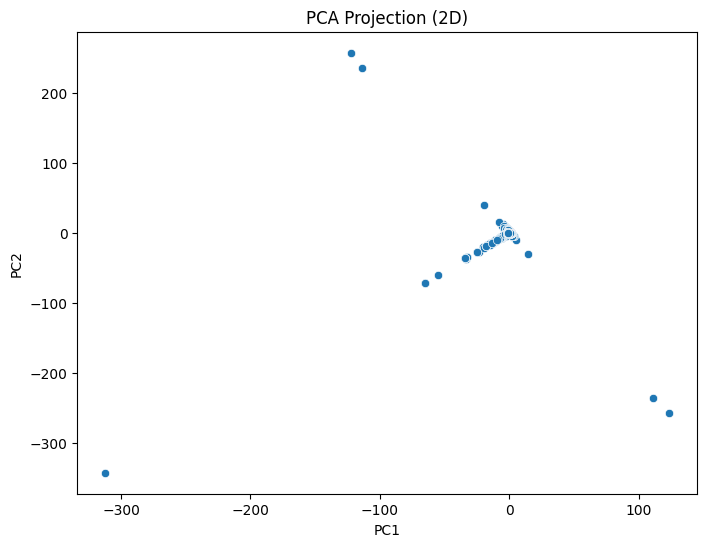

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
numeric_df = df.select_dtypes(include='number').dropna()

scaled = StandardScaler().fit_transform(numeric_df)

pca = PCA(n_components=2)
components = pca.fit_transform(scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=components[:, 0], y=components[:, 1])
plt.title('PCA Projection (2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

C:\Users\mike\AppData\Local\Temp\ipykernel_7912\3464755940.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=non_null_counts.index, y=non_null_counts.values, palette="Set2")


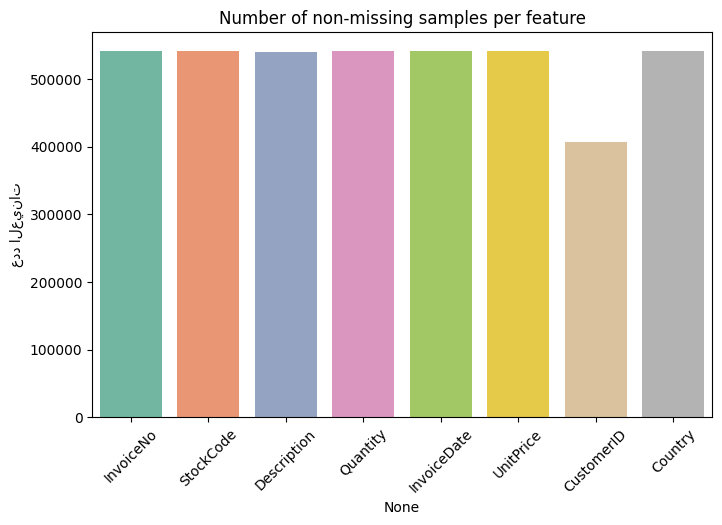

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# استخرج عدد القيم غير المفقودة لكل متغير
non_null_counts = df.count()

# رسم بياني شريطي
plt.figure(figsize=(8, 5))
sns.barplot(x=non_null_counts.index, y=non_null_counts.values, palette="Set2")
plt.title("Number of non-missing samples per feature")
plt.ylabel("عدد العينات")
plt.xticks(rotation=45)
plt.show()

In [3]:

df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [4]:
df = df.dropna()
df = df.drop_duplicates()

In [5]:

df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [6]:
df.drop(columns=['InvoiceNo','StockCode', 'Description','InvoiceDate'],axis = 1,inplace = True)


In [7]:
len(df['UnitPrice'].unique())


620

In [8]:
len(df['Quantity'].unique())


436

استخراج  ميزات

In [9]:
"""
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True, errors='coerce')

# 2. احصل على تاريخ المرجع (آخر تاريخ في كل البيانات)
reference_date = df['InvoiceDate'].max()

# 3. احسب آخر تاريخ شراء لكل عميل وحوّله إلى dict
last_purchase_dict = (
    df
    .groupby('CustomerID')['InvoiceDate']
    .max()
    .to_dict()
)

# 4. أنشئ عمود LastPurchaseDate عن طريق map
df['LastPurchaseDate'] = df['CustomerID'].map(last_purchase_dict)

# 5. احسب RecencyDays كفرق بالأيام بين المرجع وآخر عملية
df['RecencyDays'] = (reference_date - df['LastPurchaseDate']).dt.days
"""
df = df.drop(columns=['CustomerID'])


In [10]:
df.head(15)



,Quantity,UnitPrice,Country
0,6,2.55,United Kingdom
1,6,3.39,United Kingdom
2,8,2.75,United Kingdom
3,6,3.39,United Kingdom
4,6,3.39,United Kingdom
5,2,7.65,United Kingdom
6,6,4.25,United Kingdom
7,6,1.85,United Kingdom
8,6,1.85,United Kingdom
9,32,1.69,United Kingdom


In [10]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
def outlier_ratio_by_column(df):
    ratios = {}
    for col in df.select_dtypes(include=[np.number]).columns:
        # عزل العمود وتحويله إلى شكل مناسب
        data = df[[col]].values
        
        # إنشاء النموذج واكتشاف القيم الشاذة
        iso = IsolationForest(contamination='auto', random_state=42)
        preds = iso.fit_predict(data)
        
        # في IsolationForest: -1 تعني outlier
        outlier_count = np.sum(preds == -1)
        total = len(preds)
        ratios[col] = outlier_count / total
    
    return pd.Series(ratios, name="Outlier Ratio")

# عرض النتيجة
ratios = outlier_ratio_by_column(df)
print(ratios)

Quantity     0.124406
UnitPrice    0.214303
Name: Outlier Ratio, dtype: float64


In [11]:
df = df.dropna()
df = df.drop_duplicates()
df.isnull().sum()

Quantity     0
UnitPrice    0
Country      0
dtype: int64

In [12]:

country_counts = df['Country'].value_counts()

# حدد الدول النادرة (مثلاً التي أقل من 100 ظهور)
rare_countries = country_counts[country_counts < 100].index

# استبدل الدول النادرة بـ 'Other'
df['Country'] = df['Country'].replace(rare_countries, 'Other')

# ثم One-Hot Encoding
df = pd.get_dummies(df, columns=['Country'], drop_first=False)

In [13]:
df.head(4)

,Quantity,UnitPrice,Country_Australia,Country_Austria,Country_Belgium,Country_Channel Islands,Country_Cyprus,Country_Denmark,Country_EIRE,Country_Finland,...,Country_Norway,Country_Other,Country_Poland,Country_Portugal,Country_Singapore,Country_Spain,Country_Sweden,Country_Switzerland,Country_USA,Country_United Kingdom
0,6,2.55,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,6,3.39,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,8,2.75,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
5,2,7.65,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [14]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

scaled_values = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_values, columns = df.columns)
scaled_df.head(3)

,Quantity,UnitPrice,Country_Australia,Country_Austria,Country_Belgium,Country_Channel Islands,Country_Cyprus,Country_Denmark,Country_EIRE,Country_Finland,...,Country_Norway,Country_Other,Country_Poland,Country_Portugal,Country_Singapore,Country_Spain,Country_Sweden,Country_Switzerland,Country_USA,Country_United Kingdom
0,0.500037,0.000065,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.500037,0.000087,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.500049,0.000071,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [25]:
df.to_csv('cleaned_data.csv', index=False)

In [26]:
import pandas as pd 
df = pd.read_csv('cleaned_data.csv')

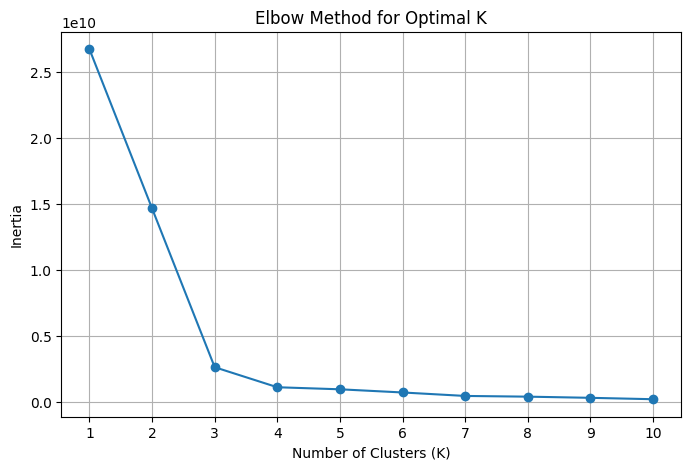

In [15]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

# حدد البيانات التي تريد تطبيق KMeans عليها (بعد الترميز والتوحيد)
X = df  # ← تأكد أنك استعملت StandardScaler أو MinMaxScaler قبلها

# قائمة لتخزين قيم الـ inertia (مجموع المسافات داخل الكلاستر)
inertias = []

# جرّب قيم K من 1 إلى 10 (يمكنك تغييره مثلاً إلى 15)
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# رسم منحنى Elbow
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(K_range)
plt.grid(True)
plt.show()


In [17]:
from sklearn.cluster import KMeans

# ← 1. عدد المجموعات الذي اخترته من Elbow (عدّله إذا وجدت الأفضل)
optimal_k = 4

# ← 2. تطبيق KMeans على البيانات
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['Cluster'] = kmeans.fit_predict(df)

# ← 3. عرض عدد العناصر في كل Cluster
print("عدد العينات في كل Cluster:")
print(df['Cluster'].value_counts().sort_index())


عدد العينات في كل Cluster:
Cluster
0    12097
1        2
2        2
3        1
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import silhouette_score

# ← 1. تحديد الأعمدة الرقمية (واستبعاد عمود Cluster)
numeric_cols = df.select_dtypes(include='number').columns.drop('Cluster')
X = df[numeric_cols]

# ← 2. حساب Silhouette Score
score = silhouette_score(X, df['Cluster'])
print(f"Silhouette Score: {score:.4f}")



Silhouette Score: 0.9964
